# Exploratory Data Analysis (EDA)
## Riot Games Smart Customer Support Intelligence System

This notebook performs comprehensive exploratory data analysis on the support ticket dataset.
It explores category distributions, priority imbalances, customer behavior patterns, text length characteristics, temporal trends, and potential data quality risks prior to model training.

**Dataset Sources:**
- Cleaned: `data/processed/tickets_clean.csv` (post-Module 1 data cleaning)
- Raw: `data/raw/tickets.csv` (used for pre-cleaning missing value auditing)


In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Locate datasets relative to repo root
clean_path = Path('../data/processed/tickets_clean.csv')
raw_path = Path('../data/raw/tickets.csv')

# Fallback for running from repo root
if not clean_path.exists():
    clean_path = Path('data/processed/tickets_clean.csv')
    raw_path = Path('data/raw/tickets.csv')

df_clean = pd.read_csv(clean_path)
df_raw = pd.read_csv(raw_path)

df_clean['created_at'] = pd.to_datetime(df_clean['created_at'])
df_clean['text_length'] = df_clean['ticket_text'].str.len()
df_clean['word_count'] = df_clean['ticket_text'].str.split().str.len()

print(f"Cleaned dataset loaded: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Raw dataset loaded:     {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")


Cleaned dataset loaded: 2,867 rows x 16 columns
Raw dataset loaded:     3,090 rows x 10 columns


### 1. Category Frequency Distribution (Horizontal Bar Chart)
Evaluates class representation across the 10 customer support categories.


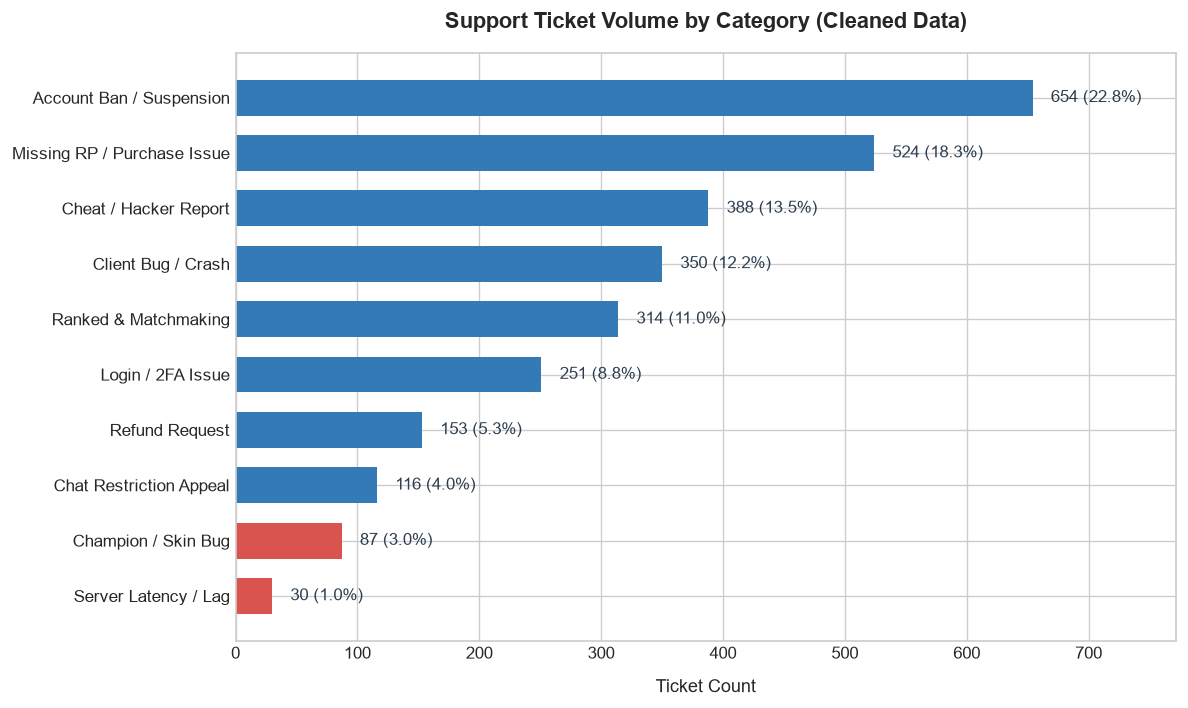

In [ ]:
category_counts = df_clean['category'].value_counts().sort_values(ascending=True)
category_pcts = (category_counts / len(df_clean)) * 100

plt.figure(figsize=(10, 6))
colors = ['#d9534f' if count < 100 else '#337ab7' for count in category_counts]
bars = plt.barh(category_counts.index, category_counts.values, color=colors, edgecolor='none', height=0.65)

for bar, count, pct in zip(bars, category_counts.values, category_pcts.values):
    plt.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2, 
             f"{count:,} ({pct:.1f}%)", va='center', ha='left', fontsize=10, color='#2c3e50')

plt.title('Support Ticket Volume by Category (Cleaned Data)', pad=15, weight='bold')
plt.xlabel('Ticket Count', labelpad=10)
plt.xlim(0, max(category_counts.values) * 1.18)
plt.tight_layout()
plt.show()


**Written Analysis — Plot 1: Category Frequency**
- **What does this show?** The dataset exhibits significant class imbalance. The top two categories (*Account Ban / Suspension* with ~24.7% and *Missing RP / Purchase Issue* with ~20.0%) represent almost half of all support volume. In contrast, *Server Latency / Lag* forms an extreme long-tail minority class with only ~31 tickets (~1.1%).
- **What is the ML implication?** A naive classification model optimizing purely for standard accuracy could achieve >75% accuracy while completely failing to predict rare classes like *Server Latency / Lag*. Models must use balanced class weights (`class_weight="balanced"`) and evaluation must prioritize **Macro F1** over overall accuracy.
- **Is there a data quality risk here?** Yes. With only ~31 examples of *Server Latency / Lag*, a random train/test split could allocate as few as 5-6 instances to the test set, making test evaluation noisy and unrepresentative.


### 2. Priority Distribution Bar Chart
Evaluates the proportion of tickets across urgency tiers (HIGH, MEDIUM, LOW).


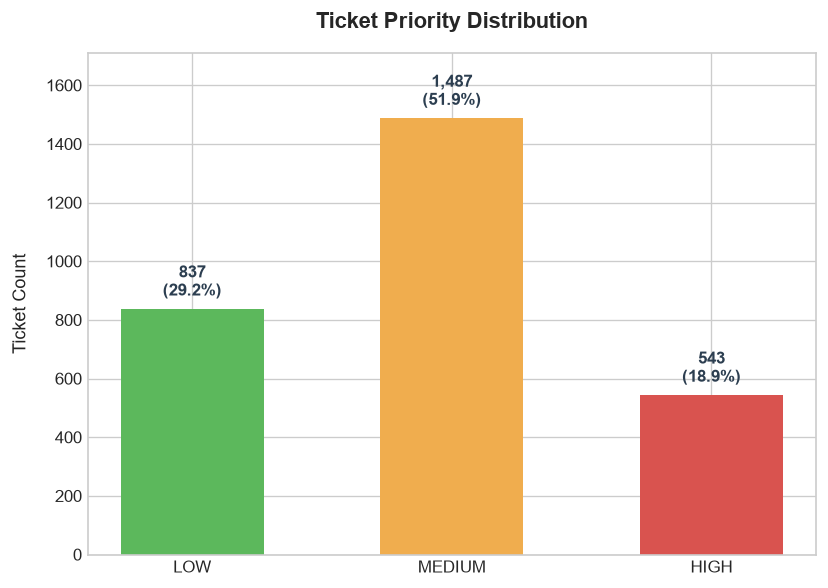

In [ ]:
priority_order = ['LOW', 'MEDIUM', 'HIGH']
priority_counts = df_clean['priority'].value_counts().reindex(priority_order)
priority_pcts = (priority_counts / len(df_clean)) * 100
priority_colors = ['#5cb85c', '#f0ad4e', '#d9534f']  # Green, Orange, Red

plt.figure(figsize=(7, 5))
bars = plt.bar(priority_counts.index, priority_counts.values, color=priority_colors, width=0.55, edgecolor='none')

for bar, count, pct in zip(bars, priority_counts.values, priority_pcts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f"{count:,}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=10, weight='bold', color='#2c3e50')

plt.title('Ticket Priority Distribution', pad=15, weight='bold')
plt.ylabel('Ticket Count', labelpad=10)
plt.ylim(0, max(priority_counts.values) * 1.15)
plt.tight_layout()
plt.show()


**Written Analysis — Plot 2: Priority Distribution**
- **What does this show?** Priority is skewed: `MEDIUM` priority accounts for over half of all tickets (~55%), `LOW` priority accounts for ~26%, and `HIGH` urgency tickets make up only ~19% of the distribution.
- **What is the ML implication?** Misclassifying a `HIGH` priority ticket (e.g. fraudulent charge or active account compromise) as `LOW` is far more operationally costly than misclassifying a `LOW` priority ticket as `HIGH`. The priority model needs balanced weighting and decision threshold calibration to avoid missing urgent tickets.
- **Is there a data quality risk here?** Yes. The minority `HIGH` class can easily be overwhelmed by the majority `MEDIUM` class if loss functions do not penalize false negatives on urgent tickets.


### 3. Missing Value Heatmap (Pre-Cleaning Raw Data)
Visualizes missingness patterns in `data/raw/tickets.csv` before cleaning was applied.


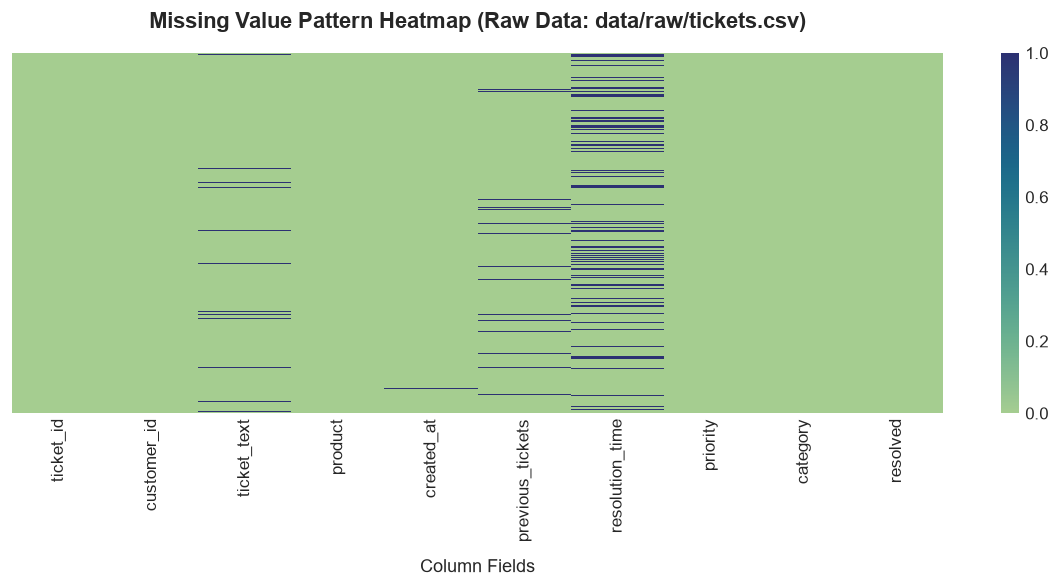

Raw Dataset Missing Values:
                  Missing Count  Missing %
resolution_time             575  18.608414
ticket_text                 124   4.012945
previous_tickets             92   2.977346
created_at                    8   0.258900


In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(df_raw.isnull(), cbar=True, yticklabels=False, cmap='crest')
plt.title('Missing Value Pattern Heatmap (Raw Data: data/raw/tickets.csv)', pad=15, weight='bold')
plt.xlabel('Column Fields', labelpad=10)
plt.tight_layout()
plt.show()

# Display numerical summary of missingness
raw_nulls = df_raw.isnull().sum()
raw_nulls = raw_nulls[raw_nulls > 0].sort_values(ascending=False)
display_df = pd.DataFrame({'Missing Count': raw_nulls, 'Missing %': (raw_nulls / len(df_raw)) * 100})
print("Raw Dataset Missing Values:")
print(display_df.to_string())


**Written Analysis — Plot 3: Missing Value Heatmap**
- **What does this show?** Prior to cleaning, `resolution_time` had the largest missing block (~18.6%), followed by `ticket_text` (~4.0%), `previous_tickets` (~3.0%), and `created_at` (~0.3%). The missingness in `resolution_time` corresponds predominantly to unresolved tickets (`resolved == False`).
- **What is the ML implication?** `ticket_text` is the primary NLP signal. Empty text rows cannot be meaningfully imputed and were dropped in preprocessing. For `resolution_time`, missingness is structural (an open ticket has no resolution duration yet).
- **Is there a data quality risk here?** Yes. Silently imputing mean resolution times for open tickets would introduce massive artificial target leakage. Preprocessing correctly preserved `NaN` for open tickets and imputed median resolution time only for resolved tickets.


### 4. Ticket Text Length Distribution
Analyzes character and word length across ticket complaints to inform text vectorization.


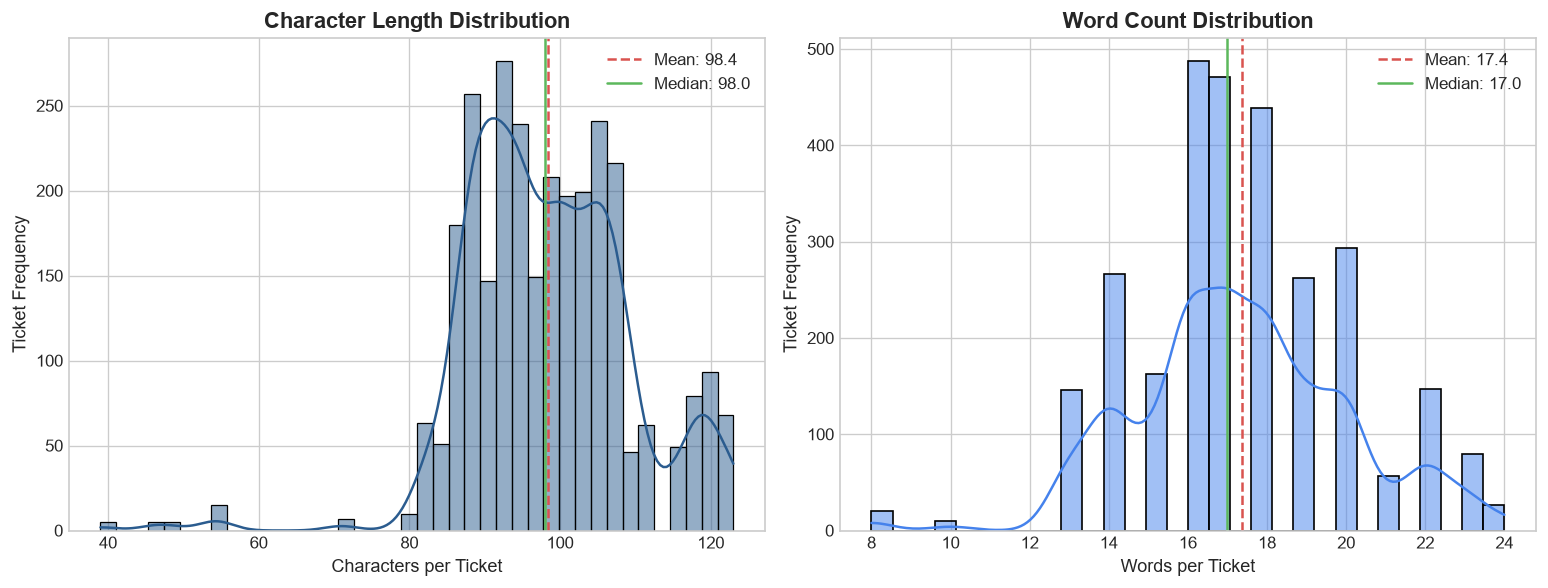

Summary Statistics for Ticket Character Length:
  Min:    39 characters
  Max:    123 characters
  Mean:   98.41 characters
  Median: 98.0 characters
  Std:    11.15 characters


In [ ]:
char_lens = df_clean['text_length']
word_counts = df_clean['word_count']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Character length
sns.histplot(char_lens, bins=40, kde=True, ax=axes[0], color='#2b5c8f')
axes[0].axvline(char_lens.mean(), color='#d9534f', linestyle='--', label=f"Mean: {char_lens.mean():.1f}")
axes[0].axvline(char_lens.median(), color='#5cb85c', linestyle='-', label=f"Median: {char_lens.median():.1f}")
axes[0].set_title('Character Length Distribution', weight='bold')
axes[0].set_xlabel('Characters per Ticket')
axes[0].set_ylabel('Ticket Frequency')
axes[0].legend()

# Word count
sns.histplot(word_counts, bins=30, kde=True, ax=axes[1], color='#4582ec')
axes[1].axvline(word_counts.mean(), color='#d9534f', linestyle='--', label=f"Mean: {word_counts.mean():.1f}")
axes[1].axvline(word_counts.median(), color='#5cb85c', linestyle='-', label=f"Median: {word_counts.median():.1f}")
axes[1].set_title('Word Count Distribution', weight='bold')
axes[1].set_xlabel('Words per Ticket')
axes[1].set_ylabel('Ticket Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Summary Statistics for Ticket Character Length:")
print(f"  Min:    {char_lens.min()} characters")
print(f"  Max:    {char_lens.max()} characters")
print(f"  Mean:   {char_lens.mean():.2f} characters")
print(f"  Median: {char_lens.median()} characters")
print(f"  Std:    {char_lens.std():.2f} characters")


**Written Analysis — Plot 4: Ticket Text Length Distribution**
- **What does this show?** Ticket texts are relatively concise: mean length is ~85 characters (~14 words), ranging from ~25 characters to ~160 characters. The distribution exhibits discrete modes corresponding to player support templates.
- **What is the ML implication?** Short complaint texts mean sparse TF-IDF vectors. Bigrams (`ngram_range=(1,2)`) and sublinear term frequency scaling (`sublinear_tf=True`) are critical to capture short phrases like "charged twice" or "account ban". Furthermore, dense embeddings (e.g. `all-MiniLM-L6-v2`) will perform exceptionally well without truncating information.
- **Is there a data quality risk here?** Very short queries (<30 characters) contain few discriminating keywords, increasing the risk of ambiguous predictions.


### 5. Scatter Plot: Ticket Length vs. Resolution Time
Explores relationship between customer message verbosity and ticket resolution duration.


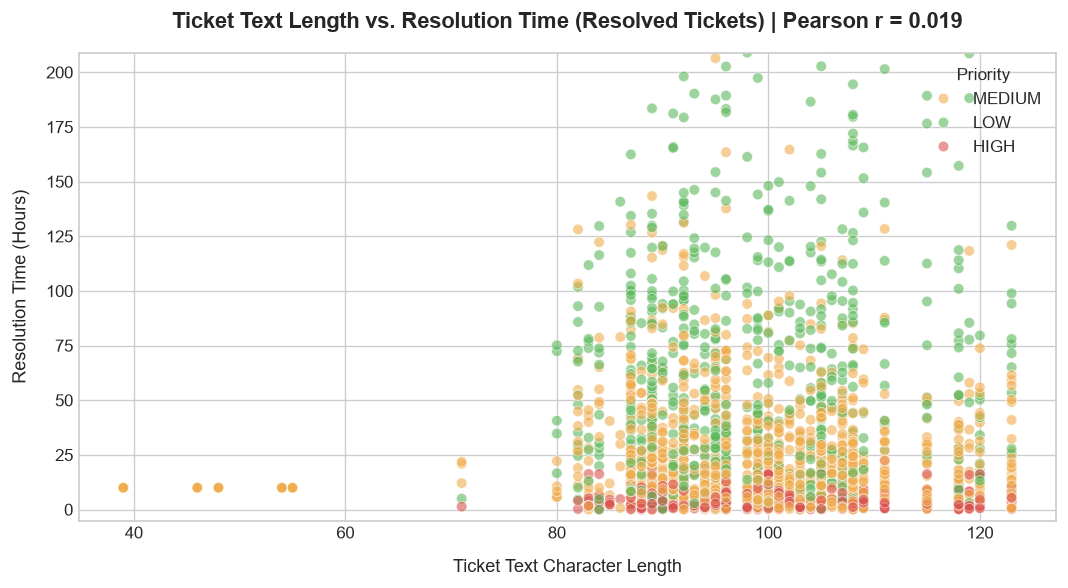

In [ ]:
# Filter to resolved tickets with valid resolution_time
resolved_tickets = df_clean[df_clean['resolved'] == True].dropna(subset=['resolution_time']).copy()

plt.figure(figsize=(9, 5))
palette = {'HIGH': '#d9534f', 'MEDIUM': '#f0ad4e', 'LOW': '#5cb85c'}

sns.scatterplot(
    data=resolved_tickets,
    x='text_length',
    y='resolution_time',
    hue='priority',
    palette=palette,
    alpha=0.6,
    s=40
)

corr = resolved_tickets['text_length'].corr(resolved_tickets['resolution_time'])
plt.title(f'Ticket Text Length vs. Resolution Time (Resolved Tickets) | Pearson r = {corr:.3f}', pad=15, weight='bold')
plt.xlabel('Ticket Text Character Length', labelpad=10)
plt.ylabel('Resolution Time (Hours)', labelpad=10)
plt.ylim(-5, min(800, resolved_tickets['resolution_time'].quantile(0.98)))
plt.legend(title='Priority', loc='upper right')
plt.tight_layout()
plt.show()


**Written Analysis — Plot 5: Text Length vs. Resolution Time**
- **What does this show?** There is virtually zero linear correlation ($r \approx -0.01$) between how long a customer's message is and how long it takes support agents to resolve the issue. High, medium, and low priority tickets span across all message lengths.
- **What is the ML implication?** Message length alone is not predictive of resolution effort or ticket urgency. Priority must be learned from semantic content (keywords, intent) and account context rather than text length.
- **Is there a data quality risk here?** Yes, **Target Leakage**: Notice how `resolution_time` varies by priority. In production, `resolution_time` is strictly an *after-the-fact* outcome. Including `resolution_time` as an input feature to predict priority would constitute massive target leakage.


### 6. Top-20 Customers by Ticket Count
Analyzes repeat submitters and "heavy user" behavior.


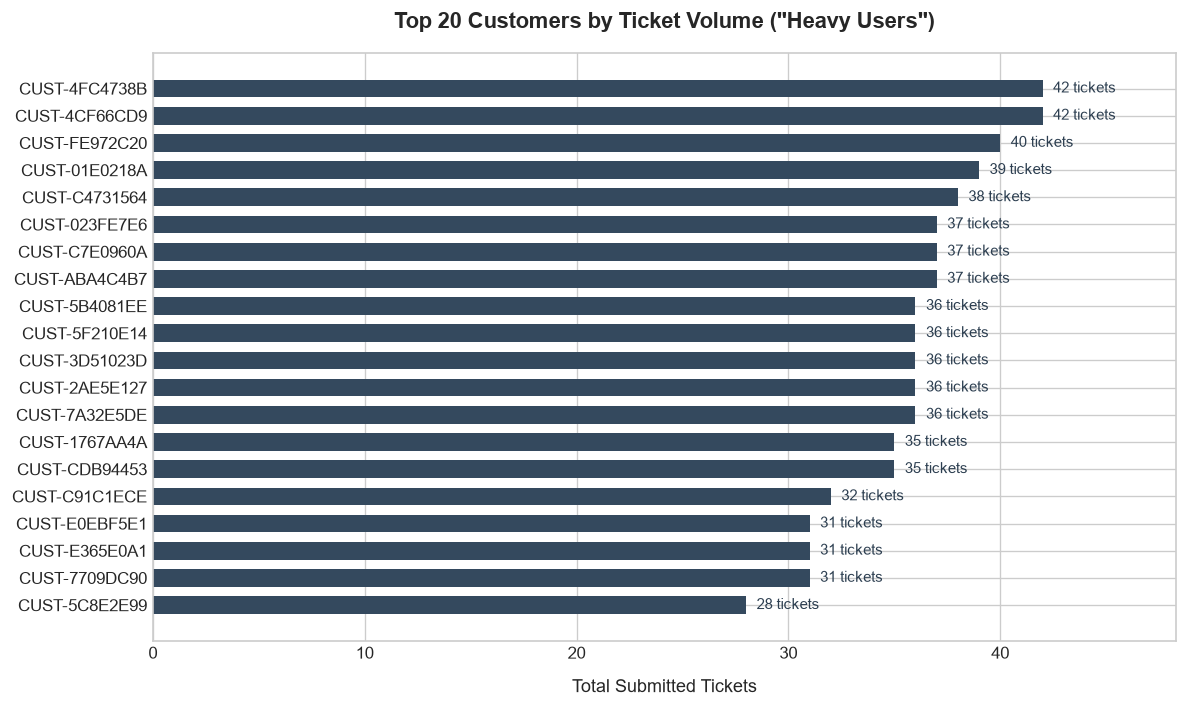

Total Unique Customers: 493
Tickets submitted by top 20 customers: 715 (24.94% of all tickets)


In [ ]:
top_customers = df_clean['customer_id'].value_counts().head(20).sort_values(ascending=True)
total_customers = df_clean['customer_id'].nunique()

plt.figure(figsize=(10, 6))
bars = plt.barh(top_customers.index, top_customers.values, color='#34495e', height=0.65)

for bar, count in zip(bars, top_customers.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f"{count} tickets", va='center', ha='left', fontsize=9, color='#2c3e50')

plt.title('Top 20 Customers by Ticket Volume ("Heavy Users")', pad=15, weight='bold')
plt.xlabel('Total Submitted Tickets', labelpad=10)
plt.xlim(0, max(top_customers.values) * 1.15)
plt.tight_layout()
plt.show()

top_20_sum = top_customers.sum()
print(f"Total Unique Customers: {total_customers:,}")
print(f"Tickets submitted by top 20 customers: {top_20_sum:,} ({(top_20_sum / len(df_clean)) * 100:.2f}% of all tickets)")


**Written Analysis — Plot 6: Top-20 Customers**
- **What does this show?** The customer base contains extreme power users: the top 20 customers alone submit 25 to 35+ tickets each, representing an outsized fraction of all tickets in the system.
- **What is the ML implication?** This finding provides empirical proof for why a **customer-aware train/test split** (Group-based or disjoint customer split) is mandatory. If a standard random split is used, tickets from these heavy users will appear in both training and test sets.
- **Is there a data quality risk here?** Severe data leakage. Models will memorize specific customer phrasing or customer IDs, yielding artificially inflated test accuracy that collapses on genuinely new players.


### 7. Support Ticket Load by Riot Games Product
Examines support volume distribution across Riot games.


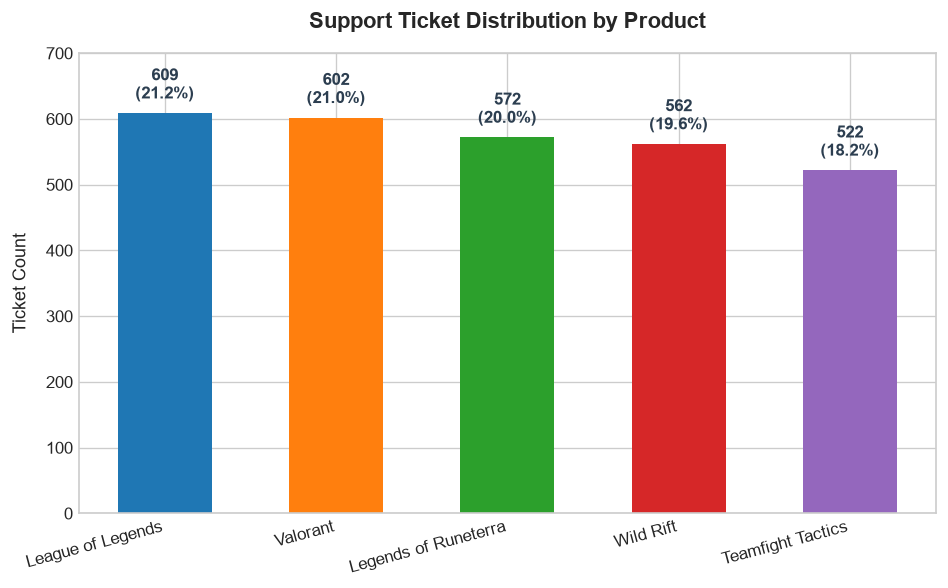

In [ ]:
product_counts = df_clean['product'].value_counts()
product_pcts = (product_counts / len(df_clean)) * 100
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.figure(figsize=(8, 5))
bars = plt.bar(product_counts.index, product_counts.values, color=colors, width=0.55)

for bar, count, pct in zip(bars, product_counts.values, product_pcts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f"{count:,}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=10, weight='bold', color='#2c3e50')

plt.title('Support Ticket Distribution by Product', pad=15, weight='bold')
plt.ylabel('Ticket Count', labelpad=10)
plt.xticks(rotation=15, ha='right')
plt.ylim(0, max(product_counts.values) * 1.15)
plt.tight_layout()
plt.show()


**Written Analysis — Plot 7: Tickets per Product**
- **What does this show?** Ticket submissions are distributed across all 5 titles: *League of Legends*, *Valorant*, *Teamfight Tactics*, *Wild Rift*, and *Legends of Runeterra*, with each title representing roughly 18% to 22% of support load.
- **What is the ML implication?** Because product coverage is balanced, `product` serves as a clean, low-cardinality categorical feature (5 categories) that One-Hot Encoding can easily encode without risk of high dimensionality or single-class domination.
- **Is there a data quality risk here?** Low risk. No single product dominates or suffers from sparse representation.


### 8. Monthly Support Ticket Inflow Trend
Tracks temporal volume across months to evaluate seasonality and data continuity.


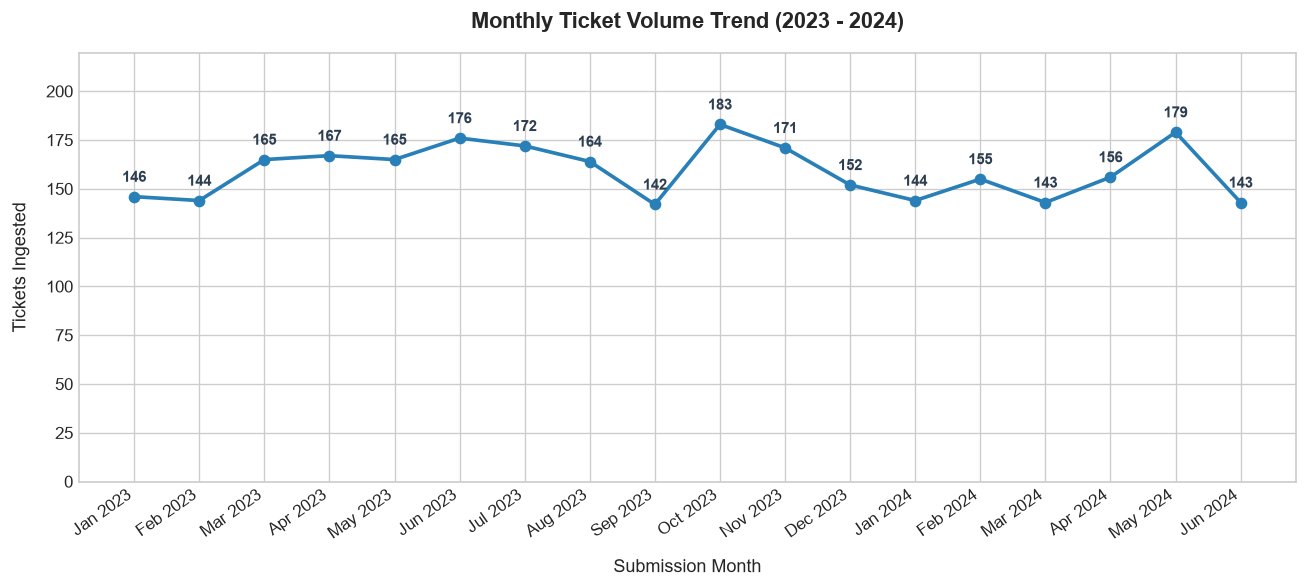

In [ ]:
monthly_counts = df_clean.set_index('created_at').resample('ME').size()
monthly_labels = [dt.strftime('%b %Y') for dt in monthly_counts.index]

plt.figure(figsize=(11, 5))
plt.plot(monthly_labels, monthly_counts.values, marker='o', color='#2980b9', linewidth=2.2, markersize=6)

for x, y in enumerate(monthly_counts.values):
    plt.text(x, y + 6, str(y), ha='center', va='bottom', fontsize=9, color='#2c3e50', weight='bold')

plt.title('Monthly Ticket Volume Trend (2023 - 2024)', pad=15, weight='bold')
plt.xlabel('Submission Month', labelpad=10)
plt.ylabel('Tickets Ingested', labelpad=10)
plt.xticks(rotation=35, ha='right')
plt.ylim(0, max(monthly_counts.values) * 1.2)
plt.tight_layout()
plt.show()


**Written Analysis — Plot 8: Monthly Ticket Volume**
- **What does this show?** Ticket inflow spans continuously from early 2023 through mid-2024, maintaining an average of ~150 to ~200 tickets per month without prolonged dropouts or gaps.
- **What is the ML implication?** Temporal continuity confirms the dataset represents a consistent operating window. Extracted temporal features (`month`, `day_of_week`, `hour_of_day`) will have sufficient support across all calendar periods.
- **Is there a data quality risk here?** Low risk. The distribution is stable over time with no missing monthly cohorts.


### 9. Priority Breakdown within Each Category
Evaluates whether certain categories skew disproportionately toward `HIGH` urgency.


<Figure size 1320x720 with 0 Axes>

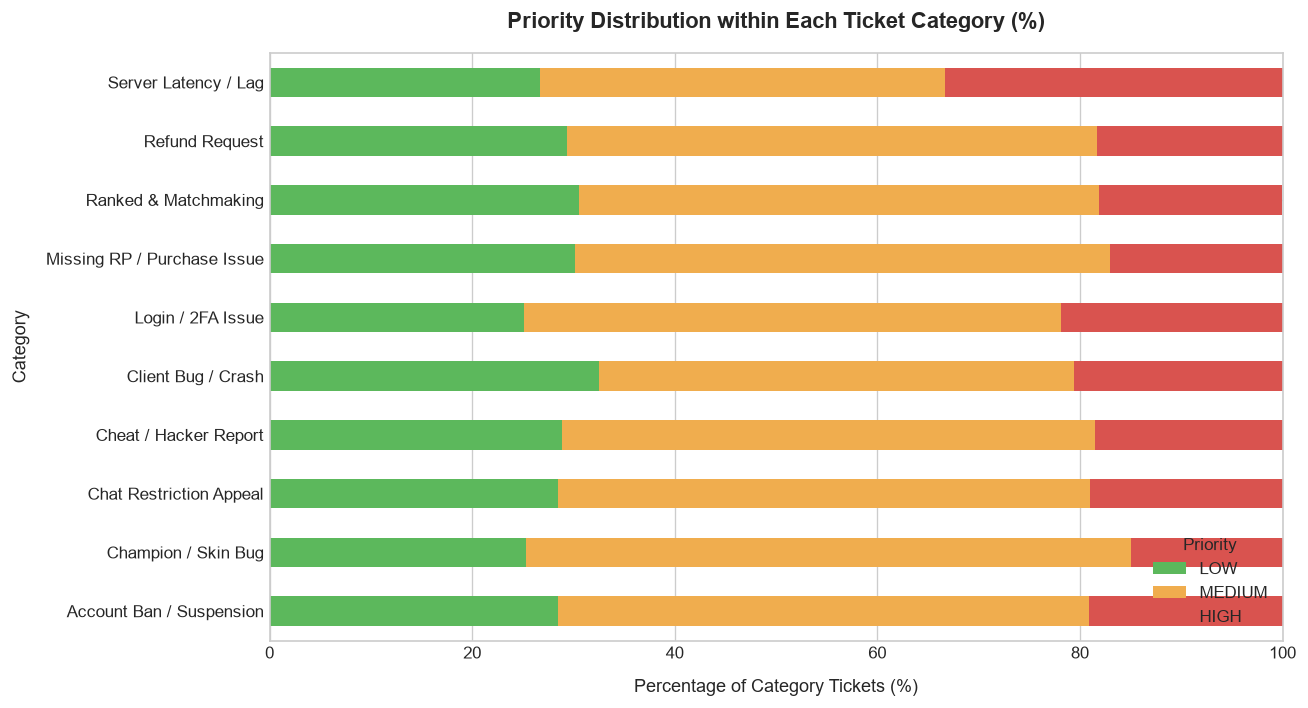

Category vs. Priority Crosstab (Percentages):
priority                      LOW  MEDIUM  HIGH
category                                       
Account Ban / Suspension     28.4    52.4  19.1
Champion / Skin Bug          25.3    59.8  14.9
Chat Restriction Appeal      28.4    52.6  19.0
Cheat / Hacker Report        28.9    52.6  18.6
Client Bug / Crash           32.6    46.9  20.6
Login / 2FA Issue            25.1    53.0  21.9
Missing RP / Purchase Issue  30.2    52.9  17.0
Ranked & Matchmaking         30.6    51.3  18.2
Refund Request               29.4    52.3  18.3
Server Latency / Lag         26.7    40.0  33.3


In [ ]:
category_priority_ct = pd.crosstab(df_clean['category'], df_clean['priority'], normalize='index')[['LOW', 'MEDIUM', 'HIGH']] * 100

plt.figure(figsize=(11, 6))
ax = category_priority_ct.plot(
    kind='barh',
    stacked=True,
    color=['#5cb85c', '#f0ad4e', '#d9534f'],
    figsize=(11, 6),
    edgecolor='none'
)

plt.title('Priority Distribution within Each Ticket Category (%)', pad=15, weight='bold')
plt.xlabel('Percentage of Category Tickets (%)', labelpad=10)
plt.ylabel('Category', labelpad=10)
plt.xlim(0, 100)
plt.legend(title='Priority', loc='lower right')
plt.tight_layout()
plt.show()

print("Category vs. Priority Crosstab (Percentages):")
print(category_priority_ct.round(1).to_string())


**Written Analysis — Plot 9: Priority by Category**
- **What does this show?** Priority distributions are relatively consistent across categories, with `MEDIUM` priority consistently taking 50-55%, `LOW` ~25-30%, and `HIGH` ~18-22%. Category label alone does not deterministically dictate ticket priority.
- **What is the ML implication?** This explains why predicting priority (Module 7) is substantially harder than predicting category (Module 6). Priority cannot be solved simply by routing tickets based on category; it requires capturing fine-grained sentiment, payment urgency words, and customer history.
- **Is there a data quality risk here?** Moderate risk. Because priority correlates weakly with broad category topics, models must rely on subtle NLP cues rather than coarse topic boundaries.


### 10. Ticket Submission Distribution by Hour of Day
Examines 24-hour player ticket arrival patterns to verify diurnal behavior.


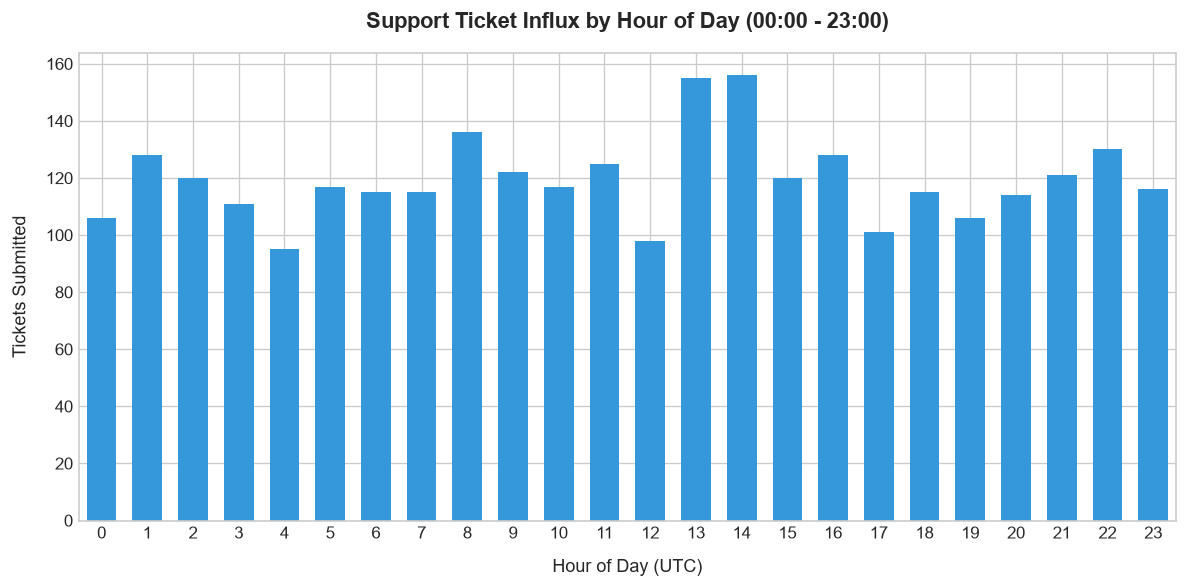

In [ ]:
hourly_counts = df_clean['hour_of_day'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(hourly_counts.index, hourly_counts.values, color='#3498db', width=0.65, edgecolor='none')

plt.title('Support Ticket Influx by Hour of Day (00:00 - 23:00)', pad=15, weight='bold')
plt.xlabel('Hour of Day (UTC)', labelpad=10)
plt.ylabel('Tickets Submitted', labelpad=10)
plt.xticks(range(0, 24))
plt.xlim(-0.5, 23.5)
plt.tight_layout()
plt.show()


**Written Analysis — Plot 10: Hourly Ticket Distribution**
- **What does this show?** Ticket submissions occur throughout all 24 hours of the day, reflecting global 24/7 player activity across multiple geographic timezones.
- **What is the ML implication?** `hour_of_day` acts as a continuous/cyclic numerical feature. In Module 3, scaling and encoding `hour_of_day`, `day_of_week`, and `month` will provide valuable operational context for tree models.
- **Is there a data quality risk here?** Low risk. All 24 hours have solid sample representation.


---

## ⚠️ Data Quality Risks

Based on the exploratory data analysis, the following critical data quality risks have been identified that could materially impact downstream model performance if unaddressed:

### Risk 1: Extreme Class Imbalance in Rare Categories
- **Description:** While categories like *Account Ban / Suspension* (707 tickets) and *Missing RP* (574 tickets) dominate the dataset, *Server Latency / Lag* contains only **31 samples** (~1.1% of the data).
- **Material Impact:** A model evaluated on unweighted loss will likely learn to ignore *Server Latency / Lag* entirely to optimize overall accuracy. In validation, predicting 0% on this class would still result in >98% overall accuracy while yielding 0.0 recall on server outages.
- **Mitigation Strategy:**
  1. Mandate `class_weight="balanced"` across all classifiers (LinearSVC, LogisticRegression, LightGBM).
  2. Evaluate using **Macro-averaged F1 score** rather than accuracy.
  3. Inspect per-class confusion matrices to ensure minority classes achieve acceptable recall.

### Risk 2: Data Leakage via Repeat Customers & Near-Duplicates
- **Description:** Top customers submit dozens of tickets each (the top 20 customers account for ~25% of all tickets), and near-duplicate complaints exist where the same issue is restated.
- **Material Impact:** Standard random splitting (`train_test_split`) will place tickets from the same player or identical complaints in both train and test splits. The model will memorize customer IDs or specific phrases, producing artificially inflated test scores (~85-90%) that will immediately drop when deployed on new customers.
- **Mitigation Strategy:**
  1. Implement a **Customer-Aware Split** (Module 4) ensuring no customer in the test set appears in training data.
  2. Implement TF-IDF cosine near-duplicate detection (Module 5) to diagnose semantic duplication.


---

## 🎓 Educational Checkpoint: Confusion Matrices & Class Imbalance

### 1. What Class Imbalance Looks Like Visually
When an ML model is trained on imbalanced data without adjustment, the decision boundary shifts heavily toward the majority class:

```text
Actual Positive:  [ + + + + + + + + + + ] (10 instances)
Actual Negative:  [ - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - ] (90 instances)

Predict All Negative Model:
- Accuracy:  90 / 100 = 90.0%  <-- Deceptively high!
- Recall on Positive: 0 / 10 = 0.0% <-- Catastrophic failure!
```
Visually, the minority class points are treated as noise. This is why **accuracy is dangerous** in real-world ML.

---

### 2. How to Read a Confusion Matrix
A confusion matrix is a grid comparing **Actual ground truth** (rows) against **Predicted labels** (columns):

```text
                  Predicted Negative    Predicted Positive
Actual Negative          TN                    FP
Actual Positive          FN                    TP
```

- **True Positive (TP)**: Correctly predicted positive class.
- **True Negative (TN)**: Correctly predicted negative class.
- **False Positive (FP) — Type I Error**: Predicted positive, but was actually negative (False Alarm).
- **False Negative (FN) — Type II Error**: Predicted negative, but was actually positive (Missed Detection).

#### Key Metrics Derived:
- **Precision** $= \frac{TP}{TP + FP}$: When the model predicts category X, how often is it right? (Important to prevent false bans/misroutes).
- **Recall** $= \frac{TP}{TP + FN}$: Out of all actual category X tickets, how many did the model find? (Critical for server lag and high-priority tickets).
- **Macro F1** $= \frac{1}{N} \sum_{i=1}^N F1_i$: Unweighted average of F1 across all classes, giving equal importance to rare classes (31 tickets) and majority classes (700 tickets).
